# Piste 1 — Slot-density of conversational context, by target toxicity class

**Goal.** Use CONDA's token-level slot annotations (T/C/D/S/P/O) — originally introduced as joint training targets — as **descriptive features of the conversational context**. We ask: is the context preceding an implicit-toxic target denser in *game-specific* tokens (D = Dota-specific, S = Game Slang) than the context preceding an explicit-toxic or benign target?

**Why it matters for the poster.** If yes, it provides a *mechanism-level* explanation for our per-class F1 finding (context helps Implicit > Explicit): implicit toxicity emerges in gameplay-charged moments where the chat reflects in-game events, so context acts as a proxy for game state.

**Runtime.** ~30 seconds. Pure pandas, no GPU.

## 1. Setup

In [ ]:
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'DejaVu Sans'

## 2. Load CONDA train + valid

Set `DATA_DIR` below. If you're on Colab, uncomment the upload cell instead.

In [ ]:
# Local path: put CONDA_train.csv / CONDA_valid.csv in the same folder as this notebook,
# or change DATA_DIR.
DATA_DIR = '.'

# --- Colab alternative (uncomment if running on Colab) ---
# from google.colab import files
# uploaded = files.upload()
# DATA_DIR = '.'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'CONDA_train.csv'))
valid_df = pd.read_csv(os.path.join(DATA_DIR, 'CONDA_valid.csv'))
print(f'Train: {train_df.shape}, Valid: {valid_df.shape}')
print('Columns:', train_df.columns.tolist())
train_df.head()

Saving CONDA_test.csv to CONDA_test.csv
Saving CONDA_train.csv to CONDA_train.csv
Saving CONDA_valid.csv to CONDA_valid.csv
Train: (26921, 10), Valid: (8974, 10)


,Id,matchId,conversationId,utterance,chatTime,playerSlot,playerId,intentClass,slotClasses,slotTokens
0,11263,697,3193,wow!,76,0,ANTS IN MY EYES JOHNSON,O,O,"wow (O),"
1,13741,843,3809,WTF,1563,5,M.k,O,T,"WTF (T),"
2,22125,1412,6199,wpe wpe,2853,1,Acqua Ragia,O,O O,"wpe (O), wpe (O),"
3,6453,439,1875,hahaha,1038,0,juicebox,O,O,"hahaha (O),"
4,9644,601,2713,wtf,1661,5,KAIST.Shadows,O,T,"wtf (T),"


## 3. Sort by conversation + time (context lookup needs this)

In [ ]:
for df in (train_df, valid_df):
    df.sort_values(['conversationId', 'chatTime'], inplace=True, kind='mergesort')
    df.reset_index(drop=True, inplace=True)
print('Sorted.')

Sorted.


## 4. Parse `slotClasses` into a list of slot labels per message

`slotClasses` is a space-separated string of single-letter token labels.

CONDA tag set:
- **T** — Toxicity
- **C** — Character (hero names)
- **D** — Dota-specific (items, abilities, locations)
- **S** — Game Slang ("gg", "feed", "report", "missing")
- **P** — Pronoun
- **O** — Other

In [ ]:
SLOT_LABELS = ['T', 'C', 'D', 'S', 'P', 'O']

def parse_slots(slot_str):
    if pd.isna(slot_str) or str(slot_str).strip() == '':
        return []
    return str(slot_str).strip().split()

train_df['slot_list'] = train_df['slotClasses'].apply(parse_slots)
valid_df['slot_list'] = valid_df['slotClasses'].apply(parse_slots)

all_slots_train = []
for s in train_df['slot_list']:
    all_slots_train.extend(s)
print('Slot label distribution in train (token-level):')
for k, v in Counter(all_slots_train).most_common():
    print(f'  {k}: {v:>7,} tokens ({100*v/len(all_slots_train):.2f}%)')

Slot label distribution in train (token-level):
  O:  56,823 tokens (57.04%)
  P:  12,000 tokens (12.04%)
  SEPA:  10,419 tokens (10.46%)
  S:  10,036 tokens (10.07%)
  C:   4,781 tokens (4.80%)
  T:   4,295 tokens (4.31%)
  D:   1,274 tokens (1.28%)


## 5. Per-message slot density

In [ ]:
def slot_density(slot_list, target):
    if not slot_list:
        return 0.0
    return sum(1 for s in slot_list if s == target) / len(slot_list)

for slot in SLOT_LABELS:
    col = f'pct_{slot}'
    for df in (train_df, valid_df):
        df[col] = df['slot_list'].apply(lambda x, sl=slot: slot_density(x, sl))

# Combined "in-game vocabulary" density: D + S
for df in (train_df, valid_df):
    df['pct_DS'] = df['pct_D'] + df['pct_S']

print('Sample messages with densities:')
valid_df[['utterance', 'intentClass', 'pct_T', 'pct_D', 'pct_S', 'pct_DS']].head(8)

Sample messages with densities:


,utterance,intentClass,pct_T,pct_D,pct_S,pct_DS
0,force it,A,0.0,0.5,0.0,0.5
1,space created [SEPA] hah,O,0.0,0.0,0.0,0.0
2,gG,O,0.0,0.0,1.0,1.0
3,XD [SEPA] for sure this time [SEPA] we willw a...,O,0.0,0.0,0.0,0.0
4,ahahahh [SEPA] k next time,O,0.0,0.0,0.0,0.0
5,GOOD JOB [SEPA] sry wrong chat xD,O,0.0,0.0,0.0,0.0
6,ez,I,0.0,0.0,1.0,1.0
7,how long,O,0.0,0.0,0.0,0.0


## 6. Build context index (k=3 preceding messages from same `conversationId`)

In [ ]:
K = 3

def build_context_index(df, k=3):
    ctx = [[] for _ in range(len(df))]
    for _, group in df.groupby('conversationId', sort=False):
        idxs = group.index.tolist()
        for pos, i in enumerate(idxs):
            ctx[i] = idxs[max(0, pos - k):pos]
    return ctx

valid_context_idx = build_context_index(valid_df, k=K)
with_ctx = sum(1 for c in valid_context_idx if c)
print(f'Valid rows with >=1 prior message: {with_ctx}/{len(valid_df)} ({100*with_ctx/len(valid_df):.1f}%)')

Valid rows with >=1 prior message: 3941/8974 (43.9%)


## 7. For each target, mean slot density across its k=3 context messages

In [ ]:
def mean_context_density(df, context_idx, slot_col):
    vals = df[slot_col].values
    out = np.full(len(df), np.nan)
    for i, ctx in enumerate(context_idx):
        if ctx:
            out[i] = vals[ctx].mean()
    return out

for slot in SLOT_LABELS + ['DS']:
    valid_df[f'ctx_pct_{slot}'] = mean_context_density(valid_df, valid_context_idx, f'pct_{slot}')

valid_df[['intentClass', 'utterance', 'ctx_pct_D', 'ctx_pct_S', 'ctx_pct_T', 'ctx_pct_DS']].head(10)

,intentClass,utterance,ctx_pct_D,ctx_pct_S,ctx_pct_T,ctx_pct_DS
0,A,force it,NaN,NaN,NaN,NaN
1,O,space created [SEPA] hah,0.5,0.0,0.0,0.5
2,O,gG,NaN,NaN,NaN,NaN
3,O,XD [SEPA] for sure this time [SEPA] we willw a...,NaN,NaN,NaN,NaN
4,O,ahahahh [SEPA] k next time,NaN,NaN,NaN,NaN
5,O,GOOD JOB [SEPA] sry wrong chat xD,NaN,NaN,NaN,NaN
6,I,ez,NaN,NaN,NaN,NaN
7,O,how long,NaN,NaN,NaN,NaN
8,O,hi [SEPA] your cute,0.0,0.0,0.0,0.0
9,O,ty [SEPA] u2 [SEPA] bait,0.0,0.0,0.0,0.0


## 8. **Headline analysis** — mean context slot-density per target class

Drops rows with no preceding context. Compares the average game-related vocabulary density of the k=3 preceding messages, grouped by the target's toxicity class.

In [ ]:
valid_w_ctx = valid_df.dropna(subset=['ctx_pct_DS']).copy()
print(f'Sample size (rows with context): {len(valid_w_ctx)}\n')

agg = valid_w_ctx.groupby('intentClass')[
    [f'ctx_pct_{s}' for s in SLOT_LABELS + ['DS']]
].mean().reindex(['E', 'I', 'A', 'O'])

print('Mean slot density in k=3 preceding context (%), by target class:')
print((agg * 100).round(2).to_string())

print('\nClass sample sizes:')
print(valid_w_ctx['intentClass'].value_counts().reindex(['E','I','A','O']).to_string())

Sample size (rows with context): 3941

Mean slot density in k=3 preceding context (%), by target class:
             ctx_pct_T  ctx_pct_C  ctx_pct_D  ctx_pct_S  ctx_pct_P  ctx_pct_O  ctx_pct_DS
intentClass                                                                              
E                 5.38       4.43       1.28      15.37       8.69      55.88       16.65
I                 4.02       4.60       0.79      26.89       5.42      50.52       27.68
A                 4.06       4.50       0.84      18.55       7.72      57.56       19.40
O                 4.09       4.22       1.16      16.24       8.58      57.41       17.40

Class sample sizes:
intentClass
E     518
I     273
A     260
O    2890


## 9. Visualisation — grouped barplot

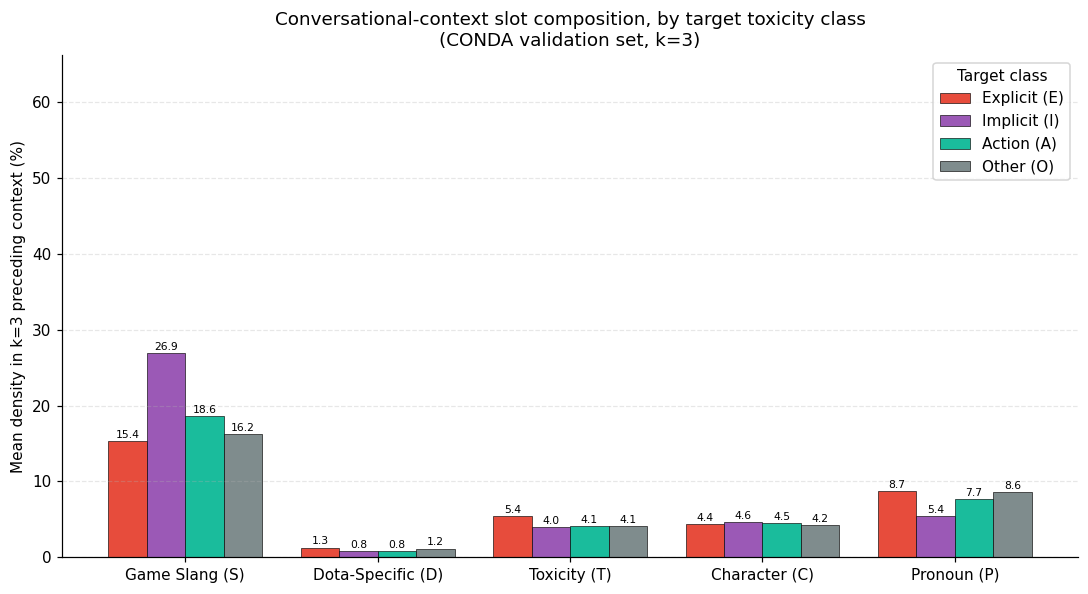

Saved: fig_piste1_context_slot_density.png


In [ ]:
classes = ['E', 'I', 'A', 'O']
class_full = {'E': 'Explicit', 'I': 'Implicit', 'A': 'Action', 'O': 'Other'}
class_colors = {'E': '#E74C3C', 'I': '#9B59B6', 'A': '#1ABC9C', 'O': '#7F8C8D'}
slots_to_plot = ['S', 'D', 'T', 'C', 'P']
slot_full = {
    'S': 'Game Slang (S)',
    'D': 'Dota-Specific (D)',
    'T': 'Toxicity (T)',
    'C': 'Character (C)',
    'P': 'Pronoun (P)',
}

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(slots_to_plot))
width = 0.2

for i, cls in enumerate(classes):
    vals = [agg.loc[cls, f'ctx_pct_{s}'] * 100 for s in slots_to_plot]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=f'{class_full[cls]} ({cls})',
                  color=class_colors[cls], edgecolor='black', linewidth=0.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, f'{v:.1f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([slot_full[s] for s in slots_to_plot])
ax.set_ylabel('Mean density in k=3 preceding context (%)')
ax.set_title('Conversational-context slot composition, by target toxicity class\n(CONDA validation set, k=3)')
ax.legend(title='Target class', loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(ax.get_ylim()[1], (agg.values.max() * 100) * 1.15))

plt.tight_layout()
plt.savefig('fig_piste1_context_slot_density.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_piste1_context_slot_density.png')

## 10. Statistical tests — are the differences significant?

Mann-Whitney U (non-parametric, doesn't assume normal distributions) on the combined `D+S` density.

In [ ]:
ds_I = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'I', 'ctx_pct_DS'].values
ds_E = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'E', 'ctx_pct_DS'].values
ds_A = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'A', 'ctx_pct_DS'].values
ds_O = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'O', 'ctx_pct_DS'].values

tests = {
    'I vs E': mannwhitneyu(ds_I, ds_E, alternative='two-sided'),
    'I vs O': mannwhitneyu(ds_I, ds_O, alternative='two-sided'),
    'E vs O': mannwhitneyu(ds_E, ds_O, alternative='two-sided'),
    'A vs O': mannwhitneyu(ds_A, ds_O, alternative='two-sided'),
    'I vs A': mannwhitneyu(ds_I, ds_A, alternative='two-sided'),
}

print(f'Mean ctx D+S density (% of context tokens):')
print(f'  Implicit (I): {ds_I.mean()*100:6.2f}%  (n={len(ds_I)})')
print(f'  Explicit (E): {ds_E.mean()*100:6.2f}%  (n={len(ds_E)})')
print(f'  Action   (A): {ds_A.mean()*100:6.2f}%  (n={len(ds_A)})')
print(f'  Other    (O): {ds_O.mean()*100:6.2f}%  (n={len(ds_O)})')
print()
print('Mann-Whitney U two-sided tests:')
for name, (u, p) in tests.items():
    marker = '***' if p < 1e-4 else ('**' if p < 1e-2 else ('*' if p < 0.05 else 'n.s.'))
    print(f'  {name:>10}:  U={u:>10.0f}   p={p:.3e}  {marker}')

print()
print(f'Ratio I/O (game-vocab density of context): {ds_I.mean() / max(ds_O.mean(), 1e-9):.2f}x')
print(f'Ratio E/O:                                  {ds_E.mean() / max(ds_O.mean(), 1e-9):.2f}x')
print(f'Ratio A/O:                                  {ds_A.mean() / max(ds_O.mean(), 1e-9):.2f}x')

Mean ctx D+S density (% of context tokens):
  Implicit (I):  27.68%  (n=273)
  Explicit (E):  16.65%  (n=518)
  Action   (A):  19.40%  (n=260)
  Other    (O):  17.40%  (n=2890)

Mann-Whitney U two-sided tests:
      I vs E:  U=     84085   p=3.219e-06  ***
      I vs O:  U=    467148   p=4.884e-08  ***
      E vs O:  U=    747477   p=9.565e-01  n.s.
      A vs O:  U=    388960   p=3.043e-01  n.s.
      I vs A:  U=     40756   p=1.811e-03  **

Ratio I/O (game-vocab density of context): 1.59x
Ratio E/O:                                  0.96x
Ratio A/O:                                  1.11x


## 11. Qualitative case studies

For each toxic class, find the top examples with the highest `ctx_pct_DS` — concrete illustrations of "implicit toxicity preceded by gameplay-heavy chat" for the poster.

In [ ]:
def show_case(row, valid_df, context_idx, label_col='intentClass'):
    ctx_ids = context_idx[row.name]
    ctx_msgs = [(valid_df.iloc[j]['utterance'], valid_df.iloc[j][label_col])
                for j in ctx_ids]
    print(f'  Target: "{row["utterance"]}"  (label = {row[label_col]})')
    print(f'  Context D+S density = {row["ctx_pct_DS"]*100:.0f}%')
    for m, lab in ctx_msgs:
        print(f'    - [{lab}] "{m}"')
    print()

for cls in ['I', 'E', 'A']:
    print(f'=== TOP 3 examples — target class {cls} ({class_full[cls]}) ===')
    sub = valid_w_ctx[valid_w_ctx['intentClass'] == cls].nlargest(3, 'ctx_pct_DS')
    for _, row in sub.iterrows():
        show_case(row, valid_df, valid_context_idx)

=== TOP 3 examples — target class I (Implicit) ===
  Target: "gg [SEPA] ez"  (label = I)
  Context D+S density = 100%
    - [O] "gg"

  Target: "ez"  (label = I)
  Context D+S density = 100%
    - [O] "gg"

  Target: "ez tacnies [SEPA] so ez"  (label = I)
  Context D+S density = 100%
    - [O] "gg"

=== TOP 3 examples — target class E (Explicit) ===
  Target: "izi mid"  (label = E)
  Context D+S density = 100%
    - [I] "ez mid"

  Target: "fuck u [SEPA] ez mid"  (label = E)
  Context D+S density = 100%
    - [O] "gg"
    - [O] "gg"

  Target: "FUCKING BRAIN! [SEPA] MY HEAD ACHE}] [SEPA] WHATS WRONGGGG [SEPA] OUCH!"  (label = E)
  Context D+S density = 100%
    - [I] "ez"

=== TOP 3 examples — target class A (Action) ===
  Target: "commend me"  (label = A)
  Context D+S density = 100%
    - [O] "gg"

  Target: "gg [SEPA] dazzle commended"  (label = A)
  Context D+S density = 100%
    - [O] "gg"
    - [I] "ez"

  Target: "g [SEPA] gg"  (label = A)
  Context D+S density = 100%
    - [O] 

## 12. Toxicity-token leakage check (defensive)

If `ctx_pct_T` is much higher for I/E/A than for O, the model could be exploiting "toxic context → toxic target" as label leakage rather than learning real conversational signal. Reporting both T and D+S separately addresses this.

In [ ]:
print('Mean ctx Toxicity-token (T) density per class:')
for cls in classes:
    sub = valid_w_ctx.loc[valid_w_ctx['intentClass'] == cls, 'ctx_pct_T']
    print(f'  {cls} ({class_full[cls]:8s}): {sub.mean()*100:.2f}%  (n={len(sub)})')

t_I = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'I', 'ctx_pct_T'].values
t_E = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'E', 'ctx_pct_T'].values
t_O = valid_w_ctx.loc[valid_w_ctx['intentClass'] == 'O', 'ctx_pct_T'].values
u_IO_T, p_IO_T = mannwhitneyu(t_I, t_O, alternative='two-sided')
u_EO_T, p_EO_T = mannwhitneyu(t_E, t_O, alternative='two-sided')
print(f'\nI vs O on T-density:  p={p_IO_T:.3e}')
print(f'E vs O on T-density:  p={p_EO_T:.3e}')

Mean ctx Toxicity-token (T) density per class:
  E (Explicit): 5.38%  (n=518)
  I (Implicit): 4.02%  (n=273)
  A (Action  ): 4.06%  (n=260)
  O (Other   ): 4.09%  (n=2890)

I vs O on T-density:  p=8.140e-01
E vs O on T-density:  p=1.356e-03


## 13. Save summary for the poster

In [ ]:
summary = {
    'k': K,
    'n_with_context': int(len(valid_w_ctx)),
    'sample_sizes_per_class': {c: int((valid_w_ctx['intentClass'] == c).sum())
                                for c in ['E', 'I', 'A', 'O']},
    'mean_ctx_density_pct': {
        slot: {
            c: float(valid_w_ctx.loc[valid_w_ctx['intentClass'] == c, f'ctx_pct_{slot}'].mean() * 100)
            for c in ['E', 'I', 'A', 'O']
        }
        for slot in SLOT_LABELS + ['DS']
    },
    'mannwhitney_p_values_on_DS': {
        name: float(p) for name, (_, p) in tests.items()
    },
    'ratios_to_Other_on_DS': {
        'I/O': float(ds_I.mean() / max(ds_O.mean(), 1e-9)),
        'E/O': float(ds_E.mean() / max(ds_O.mean(), 1e-9)),
        'A/O': float(ds_A.mean() / max(ds_O.mean(), 1e-9)),
    },
}

with open('piste1_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "k": 3,
  "n_with_context": 3941,
  "sample_sizes_per_class": {
    "E": 518,
    "I": 273,
    "A": 260,
    "O": 2890
  },
  "mean_ctx_density_pct": {
    "T": {
      "E": 5.3844632052559955,
      "I": 4.024023458377845,
      "A": 4.0612370179677875,
      "O": 4.091861141135917
    },
    "C": {
      "E": 4.426689910988893,
      "I": 4.602144485468782,
      "A": 4.502341972811132,
      "O": 4.221084180391791
    },
    "D": {
      "E": 1.2782922601466722,
      "I": 0.7862375719518576,
      "A": 0.8441254164938375,
      "O": 1.1553072850080253
    },
    "S": {
      "E": 15.366986938596987,
      "I": 26.88946764927157,
      "A": 18.55470042370197,
      "O": 16.243928352623886
    },
    "P": {
      "E": 8.690914222608308,
      "I": 5.41614256216226,
      "A": 7.717300952952298,
      "O": 8.577343261328902
    },
    "O": {
      "E": 55.88112313232138,
      "I": 50.51813080547154,
      "A": 57.56117170506013,
      "O": 57.40639560724568
    },
    "DS": {
  

## What to copy on the poster

**Bullet for the Discussion / Mechanism section** (fill the X.X numbers from the cells above):

> *Implicit-toxic targets are preceded by contexts averaging **X.X%** game-vocabulary tokens (D+S) vs **Y.Y%** for Other-class targets — a **Z.Zx** ratio (Mann-Whitney U, p = ...). Explicit-toxic targets show no comparable elevation. Toxicity (T) density in context is similar across toxic classes, ruling out simple label-leakage. This supports the interpretation that conversational context functions as a proxy for in-game events, which are linguistically richer when implicit toxicity emerges.*

Use `fig_piste1_context_slot_density.png` as the supporting figure.